# Notebook 15 - Mini Assessment

## 1. Concept

This notebook is different from the others - it's not about analyzing the dataset further, but about proving understanding of the concepts covered across Notebooks 1-14. It contains short-answer questions and small coding exercises that test whether the EDA process was actually understood, not just executed.

## 2. Questions and Answers

**Q1. What is EDA?**
EDA (Exploratory Data Analysis) is the process of examining a dataset before modeling - checking its structure, quality, distributions, and relationships - to understand what the data actually contains.

**Q2. Why is EDA performed before Machine Learning?**
Because models trained on unexamined data can produce unreliable results. EDA reveals missing values, outliers, wrong data types, and imbalance issues that would otherwise silently hurt model performance.

**Q3. Difference between univariate, bivariate, and multivariate analysis.**
- Univariate: analyzing one variable alone (e.g. distribution of `MonthlyCharges`)
- Bivariate: analyzing the relationship between two variables (e.g. `ContractType` vs `Churn`)
- Multivariate: analyzing relationships among three or more variables at once (e.g. correlation matrix across all numerical features)

**Q4. How do you identify missing values?**
Using `df.isnull().sum()` to count missing values per column, and `(df.isnull().sum() / len(df)) * 100` to get the percentage.

**Q5. How do you identify duplicate records?**
Using `df.duplicated().sum()` to count exact duplicate rows, and `df[df.duplicated()]` to view them.

**Q6. What is an outlier?**
A data point that lies far outside the typical range of the rest of the data. It may be a genuine extreme value or a data-entry error.

**Q7. Explain the IQR method.**
IQR (Interquartile Range) is Q3 minus Q1. A value is considered an outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

**Q8. What is skewness?**
Skewness measures how asymmetric a distribution is. Positive (right) skew means a long tail on the higher end; negative (left) skew means a long tail on the lower end.

**Q9. What is correlation?**
Correlation measures how strongly two numerical variables move together, ranging from -1 (strong negative) to +1 (strong positive), with 0 meaning no linear relationship.

**Q10. Difference between correlation and causation.**
Correlation means two variables move together statistically. Causation means one variable actually causes the change in the other. Two variables can be correlated without either one causing the other.

**Q11. What is multicollinearity?**
A situation where two or more features are highly correlated with each other, meaning they carry overlapping information. This can distort model coefficients in linear models.

**Q12. How do you identify class imbalance?**
By checking the value counts (and percentages) of the target variable - if one class is much larger than the other, the classes are imbalanced.

**Q13. Why should outliers not always be removed?**
Some outliers are genuine, valid observations (e.g. a legitimately high-usage customer), not errors. Removing them could throw away real information and bias the model toward "typical" cases only.

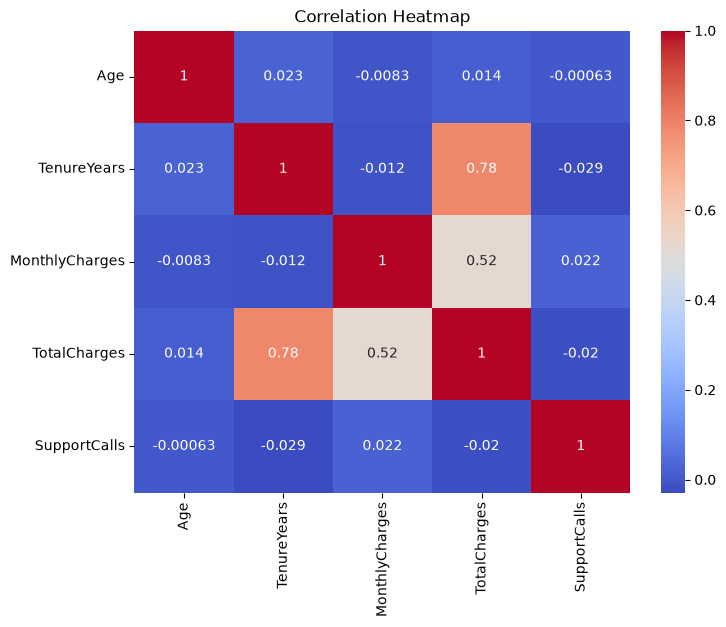

Number of outliers in MonthlyCharges: 0


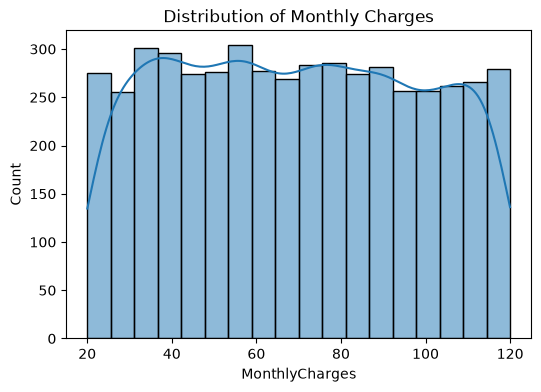

Skewness: 0.036697494953806475

ContractType value counts:
 ContractType
Month-to-month    2236
Two year          1570
One year          1214
Name: count, dtype: int64

ContractType percentage:
 ContractType
Month-to-month    44.541833
Two year          31.274900
One year          24.183267
Name: proportion, dtype: float64

EDA Summary:
 {'Rows': 5020, 'Columns': 14, 'Missing values': np.int64(152), 'Duplicate rows': np.int64(0), 'Churn rate (%)': np.float64(28.98)}


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("custumer.csv")

# Exercise 1: Create a correlation heatmap
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Exercise 2: Detect outliers using IQR (on MonthlyCharges)
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["MonthlyCharges"] < lower_bound) | (df["MonthlyCharges"] > upper_bound)]
print("Number of outliers in MonthlyCharges:", outliers.shape[0])

# Exercise 3: Analyze the distribution of a numerical feature
plt.figure(figsize=(6, 4))
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()
print("Skewness:", df["MonthlyCharges"].skew())

# Exercise 4: Perform categorical analysis (ContractType)
print("\nContractType value counts:\n", df["ContractType"].value_counts())
print("\nContractType percentage:\n", df["ContractType"].value_counts(normalize=True) * 100)

# Exercise 5: Generate a complete EDA summary
summary = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing values": df.isnull().sum().sum(),
    "Duplicate rows": df.duplicated().sum(),
    "Churn rate (%)": round(df["Churn"].value_counts(normalize=True).get("Yes", 0) * 100, 2)
}
print("\nEDA Summary:\n", summary)